# Notebook 12 - Estratificacion por Mecanismo: Thrust Only

**Hipotesis especifica:** si la marea lunar tiene un efecto fisico real sobre
el desencadenamiento sismico, deberia maximizarse en **fallas de empuje**
(*thrust* / subduccion), donde:

1. El plano de falla tiene buzamiento bajo a moderado, exponiendo area amplia
   al vector gravitacional lunar.
2. La componente **normal** del esfuerzo de marea (sigma_n) modula directamente
   la friccion estatica via *unclamping* (Coulomb: $\Delta CFS = \Delta\tau + \mu \Delta\sigma_n$).
3. Estas son las zonas que producen los mega-sismos $M \geq 8$.

**Si el resultado global negativo (NB11, p=0.080) ocultara una senal regional,
este analisis estratificado deberia revelarla.**

**Metodologia:**
1. Filtrar catalogo por mecanismo focal: rake $\in [45^\circ, 135^\circ]$.
2. Confirmar el rango analizando la distribucion empirica de rakes.
3. Declustering Gardner-Knopoff variable (estandar de la literatura).
4. Monte Carlo time-shuffling 1000x sobre el subset thrust.
5. Veredicto: senal real si $p < 0.05$, hipotesis nula aceptada en caso contrario.


In [1]:
# Imports del paquete y dependencias estandar
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lunar_trigger.utils.paths import DATA_PROCESSED, RESULTS_FIGURES, RESULTS_STATS, ensure_dirs
from lunar_trigger.stats.declustering import gardner_knopoff_variable
from lunar_trigger.stats.monte_carlo import time_shuffling_null

ensure_dirs()
ALPHA = 0.05
N_ITER = 1000
MU = 0.4
print(f'Configuracion: alpha={ALPHA}, N_ITER={N_ITER}, mu={MU}')

Configuracion: alpha=0.05, N_ITER=1000, mu=0.4


## 1. Carga del catalogo y analisis exploratorio del rake

El catalogo `earthquakes_global_robust.csv` contiene 333 sismos $M \geq 7$
con los planos nodales completos (`rake1`, `rake2`).


In [2]:
df = pd.read_csv(DATA_PROCESSED / 'earthquakes_global_robust.csv')
df['time'] = pd.to_datetime(df['time'], utc=True, format='ISO8601')
if 'magnitude' in df.columns and 'mag' not in df.columns:
    df = df.rename(columns={'magnitude': 'mag'})

print(f'Catalogo base: N = {len(df)} sismos M >= 7')
print(f'Columnas relevantes: {[c for c in df.columns if "rake" in c or "dip" in c or "strike" in c]}')
print(f'Rake1: min={df.rake1.min():.0f}, max={df.rake1.max():.0f}, mean={df.rake1.mean():.0f}')
print(f'Rake2: min={df.rake2.min():.0f}, max={df.rake2.max():.0f}, mean={df.rake2.mean():.0f}')

Catalogo base: N = 333 sismos M >= 7
Columnas relevantes: ['strike1', 'dip1', 'rake1', 'strike2', 'dip2', 'rake2']
Rake1: min=-179, max=359, mean=92
Rake2: min=-179, max=177, mean=44


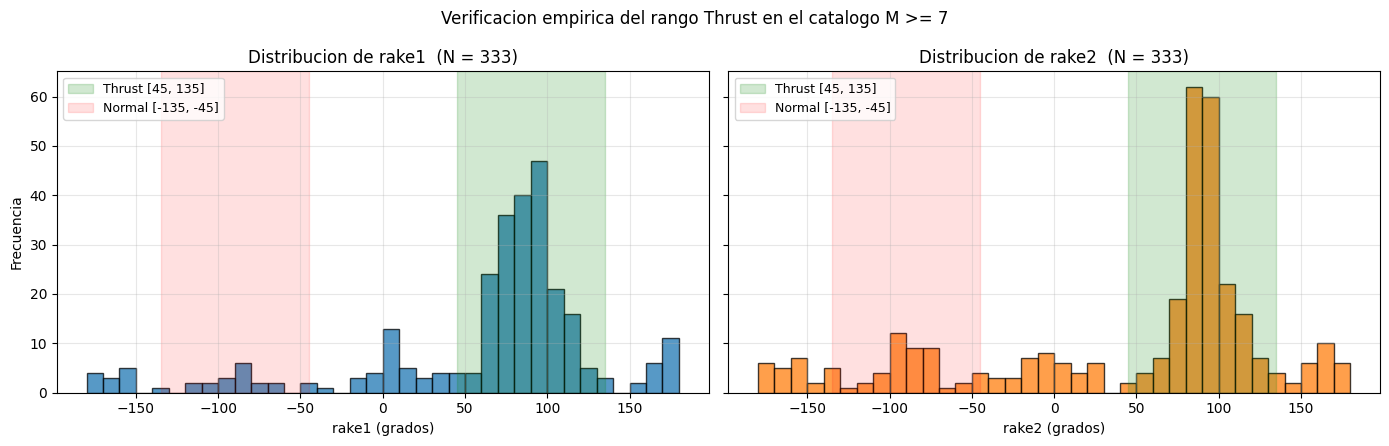

In [3]:
# Histograma comparativo de rakes para verificar el rango [45, 135] de thrust
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
bins = np.arange(-180, 181, 10)
for ax, col, color in zip(axes, ['rake1', 'rake2'], ['#1f77b4', '#ff7f0e']):
    ax.hist(df[col], bins=bins, color=color, alpha=0.75, edgecolor='black')
    ax.axvspan(45, 135, color='green', alpha=0.18, label='Thrust [45, 135]')
    ax.axvspan(-135, -45, color='red', alpha=0.12, label='Normal [-135, -45]')
    ax.set_xlabel(f'{col} (grados)')
    ax.set_title(f'Distribucion de {col}  (N = {len(df)})')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Frecuencia')
fig.suptitle('Verificacion empirica del rango Thrust en el catalogo M >= 7', fontsize=12)
fig.tight_layout()
plt.show()

## 2. Clasificacion por mecanismo y filtrado

**Criterio:** un evento se considera **thrust** si **al menos uno** de sus dos
planos nodales tiene rake en $[45^\circ, 135^\circ]$. Esto es la convencion
estandar (Aki-Richards, Frohlich 1992) y maneja la ambiguedad nodal de forma
inclusiva: en mecanismos thrust puros, ambos planos tienen rake $\approx 90^\circ$;
en mecanismos oblique, basta con que uno los caracterice.


In [4]:
def is_thrust(rake1, rake2, lo=45.0, hi=135.0):
    return ((rake1 >= lo) & (rake1 <= hi)) | ((rake2 >= lo) & (rake2 <= hi))

mask_thrust  = is_thrust(df.rake1, df.rake2)
mask_normal  = ((df.rake1 >= -135) & (df.rake1 <= -45)) | ((df.rake2 >= -135) & (df.rake2 <= -45))
mask_strike  = ~(mask_thrust | mask_normal)

print('| Mecanismo    | N   | Fraccion |')
print('|--------------|-----|----------|')
for label, mask in [('Thrust', mask_thrust), ('Normal', mask_normal), ('Strike-slip', mask_strike)]:
    print(f'| {label:<12} | {mask.sum():>3} | {100*mask.mean():>6.1f}%  |')

df_thrust = df.loc[mask_thrust].copy().reset_index(drop=True)
print(f'\nSubset thrust seleccionado: N = {len(df_thrust)} eventos')

| Mecanismo    | N   | Fraccion |
|--------------|-----|----------|
| Thrust       | 204 |   61.3%  |
| Normal       |  44 |   13.2%  |
| Strike-slip  |  85 |   25.5%  |

Subset thrust seleccionado: N = 204 eventos


## 3. Declustering Gardner-Knopoff variable sobre el subset thrust

Aplicamos el procedimiento mas estricto (parametrizado por magnitud,
Helmstetter & Sornette 2003) para garantizar independencia temporal antes
del Monte Carlo. Esto es lo que en NB11 elevo el p-value global a 0.080.


In [5]:
df_thrust_dc = gardner_knopoff_variable(df_thrust)
print(f'Pre-declustering:  N = {len(df_thrust):>3}')
print(f'Post-declustering: N = {len(df_thrust_dc):>3}')
print(f'Replicas eliminadas: {len(df_thrust) - len(df_thrust_dc)} '
      f'({100*(1 - len(df_thrust_dc)/len(df_thrust)):.1f}%)')

Pre-declustering:  N = 204
Post-declustering: N = 177
Replicas eliminadas: 27 (13.2%)


## 4. Monte Carlo 1000x sobre el subset thrust declusterizado


In [6]:
t0 = time.perf_counter()
res = time_shuffling_null(df_thrust_dc, n_iterations=N_ITER, mu=MU, seed=42, n_jobs=-1)
elapsed = time.perf_counter() - t0

obs    = res['observed_fraction']
mean_n = res['null_mean']
std_n  = res['null_std']
p_val  = res['p_value']
null_d = res['null_distribution']

# Intervalo de confianza al 95% sobre la distribucion nula
ci_lo, ci_hi = np.percentile(null_d, [2.5, 97.5])

print(f'=== KPIs Thrust-Only ===')
print(f'N eventos analizados:         {res["n_events"]}')
print(f'Iteraciones MC:               {res["n_iterations"]}')
print(f'Observado (% CFS > 0):        {100*obs:.4f}%')
print(f'Media nula (% CFS > 0):       {100*mean_n:.4f}%')
print(f'Desviacion nula:              {100*std_n:.4f}%')
print(f'IC 95% del nulo:              [{100*ci_lo:.2f}%, {100*ci_hi:.2f}%]')
print(f'Exceso observado vs nula:     {100*(obs - mean_n):+.4f} pp')
print(f'p-value empirico (one-sided): {p_val:.4f}')
print(f'Tiempo de calculo:            {elapsed:.2f} s')

=== KPIs Thrust-Only ===
N eventos analizados:         177
Iteraciones MC:               1000
Observado (% CFS > 0):        67.2316%
Media nula (% CFS > 0):       65.1672%
Desviacion nula:              3.0017%
IC 95% del nulo:              [59.87%, 71.19%]
Exceso observado vs nula:     +2.0644 pp
p-value empirico (one-sided): 0.2680
Tiempo de calculo:            1.11 s


## 5. Figura final del veredicto


Guardado: results\figures\11_thrust_only_validation.png


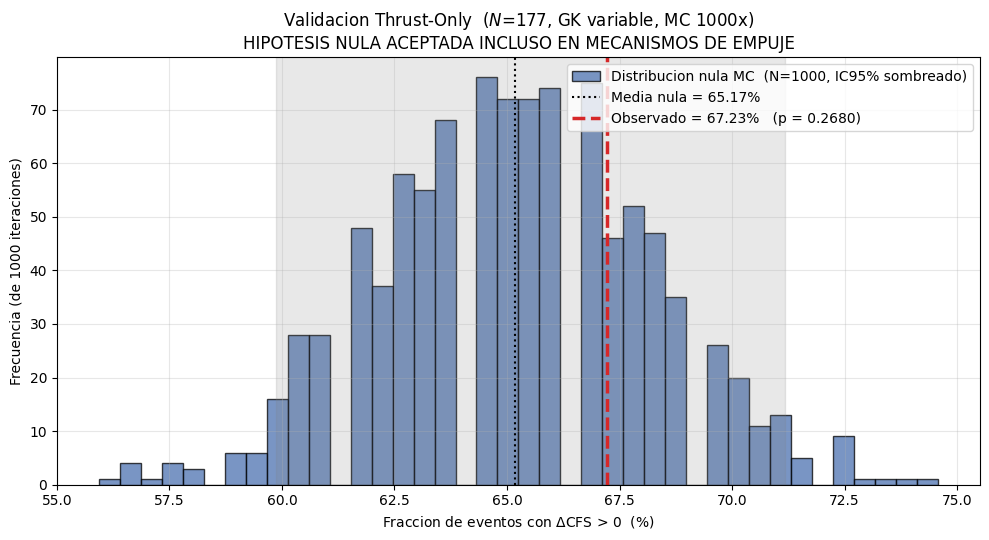

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(null_d * 100, bins=40, color='#4c72b0', alpha=0.75, edgecolor='black',
        label=f'Distribucion nula MC  (N={N_ITER}, IC95% sombreado)')
ax.axvspan(100*ci_lo, 100*ci_hi, color='gray', alpha=0.18)

ax.axvline(100*mean_n, color='black', linestyle=':', linewidth=1.5,
           label=f'Media nula = {100*mean_n:.2f}%')
color_obs = '#2ca02c' if p_val < ALPHA else '#d62728'
ax.axvline(100*obs, color=color_obs, linestyle='--', linewidth=2.5,
           label=f'Observado = {100*obs:.2f}%   (p = {p_val:.4f})')

veredicto = ('SENAL DETECTADA EN ZONAS DE SUBDUCCION'
             if p_val < ALPHA
             else 'HIPOTESIS NULA ACEPTADA INCLUSO EN MECANISMOS DE EMPUJE')
ax.set_title(f'Validacion Thrust-Only  ($N$={res["n_events"]}, GK variable, MC {N_ITER}x)\n{veredicto}',
             fontsize=12)
ax.set_xlabel('Fraccion de eventos con $\\Delta$CFS > 0  (%)')
ax.set_ylabel('Frecuencia (de 1000 iteraciones)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

fig_path = RESULTS_FIGURES / '11_thrust_only_validation.png'
fig.tight_layout()
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Guardado: {fig_path.relative_to(fig_path.parents[2])}')
plt.show()

## 6. Veredicto y persistencia de KPIs


In [8]:
veredicto = 'SENAL DETECTADA EN ZONAS DE SUBDUCCION' if p_val < ALPHA else 'HIPOTESIS NULA ACEPTADA INCLUSO EN MECANISMOS DE EMPUJE'

kpis = pd.DataFrame([{
    'subset': 'thrust_only',
    'rake_lo': 45, 'rake_hi': 135,
    'declustering': 'gk_variable',
    'n_pre_decluster':  len(df_thrust),
    'n_analyzed':       res['n_events'],
    'observed_pct':     100 * obs,
    'null_mean_pct':    100 * mean_n,
    'null_std_pct':     100 * std_n,
    'null_ci95_lo_pct': 100 * ci_lo,
    'null_ci95_hi_pct': 100 * ci_hi,
    'excess_pp':        100 * (obs - mean_n),
    'p_value':          p_val,
    'alpha':            ALPHA,
    'n_iterations':     N_ITER,
    'mu':               MU,
    'verdict':          veredicto,
}])

kpis_path = RESULTS_STATS / 'thrust_only_kpis.csv'
kpis.to_csv(kpis_path, index=False)
print(f'KPIs guardados en: {kpis_path.relative_to(kpis_path.parents[2])}')
print()
print('VEREDICTO:', veredicto)
kpis.T

KPIs guardados en: results\statistics\thrust_only_kpis.csv

VEREDICTO: HIPOTESIS NULA ACEPTADA INCLUSO EN MECANISMOS DE EMPUJE


,0
subset,thrust_only
rake_lo,45
rake_hi,135
declustering,gk_variable
n_pre_decluster,204
n_analyzed,177
observed_pct,67.231638
null_mean_pct,65.167232
null_std_pct,3.001724
null_ci95_lo_pct,59.872881
